# Gridded Thunder Reliability and Attributes Notebook

This notebook builds reliability and attributes-style diagnostics from monthly verification CSV files generated by the gridded lightning verification workflow.

## What this notebook does
1. Selects a date range and one or more thunder intervals (TSTM06 and/or TSTM12).
2. Loads monthly CSV files into one combined DataFrame.
3. Filters to valid probability bins (`count > 0`) and selected regions.
4. Produces day-vs-night reliability plots by region and interval.
5. Prints diagnostics and creates attributes diagrams.

## Required inputs
- Monthly CSV files named like `verif_06_YYYY_MM.csv` and `verif_12_YYYY_MM.csv`.
- Columns expected in each CSV include: `region`, `period`, `prob_bin`, `sum_obs`, `count`, `year`, and `month`.

## Notes
- Set `tstm_type` to `[6]`, `[12]`, or `[6, 12]`.
- Set `region_filter` to `'ALL'`, a single region string, or a list of regions.
- Plot saving is optional and is disabled by default in this notebook.

In [2]:
from pathlib import Path
from calendar import month_abbr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Folder containing monthly verification CSV files.
csv_dir = Path(r"C:\Users\David.Levin\NBMLightningVer\monthly_stats")

# Choose years and months to load.
years = range(2023, 2026)  # 2023, 2024, 2025
months = range(3, 11)      # Mar-Oct

# Build a readable label used in plot titles.
years_list = sorted({int(y) for y in years})
months_list = sorted({int(m) for m in months})
if not years_list or not months_list:
    raise ValueError("years and months must each contain at least one value.")
date_span_label = f"{years_list[0]} to {years_list[-1]} ({month_abbr[months_list[0]]} - {month_abbr[months_list[-1]]})"

# Thunder interval options: 06, 12, or both.
tstm_type = [6, 12]

type_tags = sorted({f"{int(t):02d}" for t in tstm_type})
if not type_tags:
    raise ValueError("tstm_type is empty. Use values like [6], [12], or [6, 12].")

# Build expected file list using verif_II_YYYY_MM.csv convention.
requested_items = [
    (tag, csv_dir / f"verif_{tag}_{year}_{month:02d}.csv")
    for tag in type_tags
    for year in years
    for month in months
]
csv_items = [(tag, p) for tag, p in requested_items if p.exists()]
missing_items = [(tag, p) for tag, p in requested_items if not p.exists()]

if not csv_items:
    raise FileNotFoundError(
        f"No files found for types={type_tags}, years={list(years)} and months={list(months)} in {csv_dir}"
    )

print(f"TSTM types selected: {type_tags}")
print(f"Date range label: {date_span_label}")
print(f"Files selected ({len(csv_items)}):")
for tag, p in csv_items:
    print(f" - TSTM{tag}: {p.name}")

if missing_items:
    print(f"Missing files ({len(missing_items)}):")
    for tag, p in missing_items:
        print(f" - TSTM{tag}: {p.name}")

# Region selection options:
# - 'ALL' to use all available regions found in data
# - a single region string like 'CONUS'
# - a list like ['CONUS', 'ER', 'SR']
region_filter = 'ALL'

TSTM types selected: ['06', '12']
Date range label: 2023 to 2025 (Mar - Oct)
Files selected (48):
 - TSTM06: verif_06_2023_03.csv
 - TSTM06: verif_06_2023_04.csv
 - TSTM06: verif_06_2023_05.csv
 - TSTM06: verif_06_2023_06.csv
 - TSTM06: verif_06_2023_07.csv
 - TSTM06: verif_06_2023_08.csv
 - TSTM06: verif_06_2023_09.csv
 - TSTM06: verif_06_2023_10.csv
 - TSTM06: verif_06_2024_03.csv
 - TSTM06: verif_06_2024_04.csv
 - TSTM06: verif_06_2024_05.csv
 - TSTM06: verif_06_2024_06.csv
 - TSTM06: verif_06_2024_07.csv
 - TSTM06: verif_06_2024_08.csv
 - TSTM06: verif_06_2024_09.csv
 - TSTM06: verif_06_2024_10.csv
 - TSTM06: verif_06_2025_03.csv
 - TSTM06: verif_06_2025_04.csv
 - TSTM06: verif_06_2025_05.csv
 - TSTM06: verif_06_2025_06.csv
 - TSTM06: verif_06_2025_07.csv
 - TSTM06: verif_06_2025_08.csv
 - TSTM06: verif_06_2025_09.csv
 - TSTM06: verif_06_2025_10.csv
 - TSTM12: verif_12_2023_03.csv
 - TSTM12: verif_12_2023_04.csv
 - TSTM12: verif_12_2023_05.csv
 - TSTM12: verif_12_2023_06.csv
 - TST

In [3]:
# Load selected monthly CSV files and tag each row with TSTM type + source file.
frames = []
for tag, p in csv_items:
    tmp = pd.read_csv(p)
    tmp['tstm_type'] = tag
    tmp['source_file'] = p.name
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)

# Keep only bins that have at least one forecast sample.
df = df[df['count'] > 0].copy()

available_regions = sorted(df['region'].dropna().unique())
available_types = sorted(df['tstm_type'].dropna().astype(str).unique())

# Resolve user region selection into a validated list.
if region_filter is None or region_filter == 'ALL':
    regions_to_plot = available_regions
elif isinstance(region_filter, str):
    regions_to_plot = [region_filter]
else:
    regions_to_plot = list(region_filter)

regions_to_plot = [r for r in regions_to_plot if r in available_regions]
if not regions_to_plot:
    raise ValueError('No valid regions selected. Check region_filter values.')

print(f"Rows loaded: {len(df):,}")
print(f"Files loaded: {len(csv_items):,}")
print(f"Available regions: {available_regions}")
print(f"Regions selected: {regions_to_plot}")
print(f"Periods: {sorted(df['period'].dropna().str.lower().unique())}")
print(f"TSTM types loaded: {available_types}")

Rows loaded: 8,608
Files loaded: 48
Available regions: ['Alaska']
Regions selected: ['Alaska']
Periods: ['day', 'night']
TSTM types loaded: ['06', '12']


In [ ]:
# Diagnostic: inspect where high-probability bins come from and whether they overlap observations.
#
# This works from the monthly verification CSVs already loaded into `df`.
# It helps answer questions like:
# - Are high forecast probabilities rare in Alaska?
# - Which month/source file, period, and forecast hour produced the high bins?
# - Do high-probability bins have enough sample size to interpret reliably?
# - Are observed lightning counts concentrated in the lower forecast-probability bins?

HIGH_BIN_FLOOR = 0.30       # Show bins at or above this probability.
MIN_BIN_COUNT = 1           # Increase if you want to ignore tiny-sample bins, e.g., 100 or 1000.
TOP_N = 40                  # Number of rows to print in the detailed table.

# Use selected regions from the notebook unless you want to override manually.
diag_df = df[df['region'].isin(regions_to_plot)].copy()

# Basic observed-frequency diagnostics by probability bin.
bin_summary = (
    diag_df
    .groupby(['tstm_type', 'prob_bin'], as_index=False)
    .agg(
        count=('count', 'sum'),
        sum_obs=('sum_obs', 'sum'),
        n_source_files=('source_file', 'nunique'),
    )
    .sort_values(['tstm_type', 'prob_bin'])
)

bin_summary['obs_freq'] = bin_summary['sum_obs'] / bin_summary['count']
bin_summary['obs_pct'] = 100.0 * bin_summary['obs_freq']
bin_summary['sample_pct'] = 100.0 * bin_summary['count'] / bin_summary.groupby('tstm_type')['count'].transform('sum')

print('=== Overall probability-bin summary for selected region(s) ===')
print(
    bin_summary[
        ['tstm_type', 'prob_bin', 'count', 'sample_pct', 'sum_obs', 'obs_pct', 'n_source_files']
    ].to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

# Focus on high-probability bins.
high_bins = bin_summary[bin_summary['prob_bin'] >= HIGH_BIN_FLOOR].copy()

print(f'\n=== High-probability bin summary: prob_bin >= {HIGH_BIN_FLOOR:.2f} ===')
if high_bins.empty:
    print('No rows found at or above HIGH_BIN_FLOOR. Forecasts may never reach this probability in the selected data.')
else:
    print(
        high_bins[
            ['tstm_type', 'prob_bin', 'count', 'sample_pct', 'sum_obs', 'obs_pct', 'n_source_files']
        ].to_string(index=False, float_format=lambda x: f'{x:.4f}')
    )

# Show which file / lead / period combinations are contributing to the high bins.
# This is useful for determining whether high probabilities come from many events
# or from a small number of isolated cases.
detail_group_cols = ['tstm_type', 'source_file', 'year', 'month', 'period', 'forecast_hour', 'prob_bin']

detail = (
    diag_df[diag_df['prob_bin'] >= HIGH_BIN_FLOOR]
    .groupby(detail_group_cols, as_index=False)
    .agg(
        count=('count', 'sum'),
        sum_obs=('sum_obs', 'sum'),
    )
)

detail = detail[detail['count'] >= MIN_BIN_COUNT].copy()

if not detail.empty:
    detail['obs_freq'] = detail['sum_obs'] / detail['count']
    detail['obs_pct'] = 100.0 * detail['obs_freq']
    detail = detail.sort_values(['prob_bin', 'count'], ascending=[False, False])

print(f'\n=== High-bin contributors by file / period / forecast hour: top {TOP_N} ===')
if detail.empty:
    print('No high-bin contributors after applying HIGH_BIN_FLOOR and MIN_BIN_COUNT.')
else:
    print(
        detail.head(TOP_N)[
            ['tstm_type', 'source_file', 'period', 'forecast_hour', 'prob_bin', 'count', 'sum_obs', 'obs_pct']
        ].to_string(index=False, float_format=lambda x: f'{x:.4f}')
    )

# Check the maximum populated probability bin by TSTM type and source file.
# If your big lightning cases only reach 0.3 or 0.4, then empty 0.5+ bins may be expected.
max_by_file = (
    diag_df[diag_df['count'] >= MIN_BIN_COUNT]
    .groupby(['tstm_type', 'source_file'], as_index=False)
    .agg(
        max_populated_prob_bin=('prob_bin', 'max'),
        total_count=('count', 'sum'),
        total_obs=('sum_obs', 'sum'),
    )
)
max_by_file['obs_pct'] = 100.0 * max_by_file['total_obs'] / max_by_file['total_count']
max_by_file = max_by_file.sort_values(['max_populated_prob_bin', 'total_obs'], ascending=[False, False])

print(f'\n=== Source files with highest populated forecast-probability bins: top {TOP_N} ===')
print(
    max_by_file.head(TOP_N)[
        ['tstm_type', 'source_file', 'max_populated_prob_bin', 'total_count', 'total_obs', 'obs_pct']
    ].to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

# Optional quick plot: observed frequency and sample distribution by probability bin.
for type_tag in sorted(diag_df['tstm_type'].dropna().astype(str).unique()):
    plot_df = bin_summary[bin_summary['tstm_type'].astype(str) == type_tag].copy()
    if plot_df.empty:
        continue

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(plot_df['prob_bin'], plot_df['obs_pct'], '-o', label='Observed frequency (%)')
    ax1.plot([0, 1], [0, 100], 'k--', lw=1, label='Perfect reliability')
    ax1.set_xlabel('Forecast probability bin')
    ax1.set_ylabel('Observed frequency (%)')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 100)
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.bar(plot_df['prob_bin'], plot_df['sample_pct'], width=0.035, alpha=0.25, label='Sample frequency (%)')
    ax2.set_ylabel('Sample frequency (%)')
    ax2.set_yscale('log')

    ax1.set_title(f'TSTM{type_tag} diagnostic: reliability + sample distribution\n{date_span_label}')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()



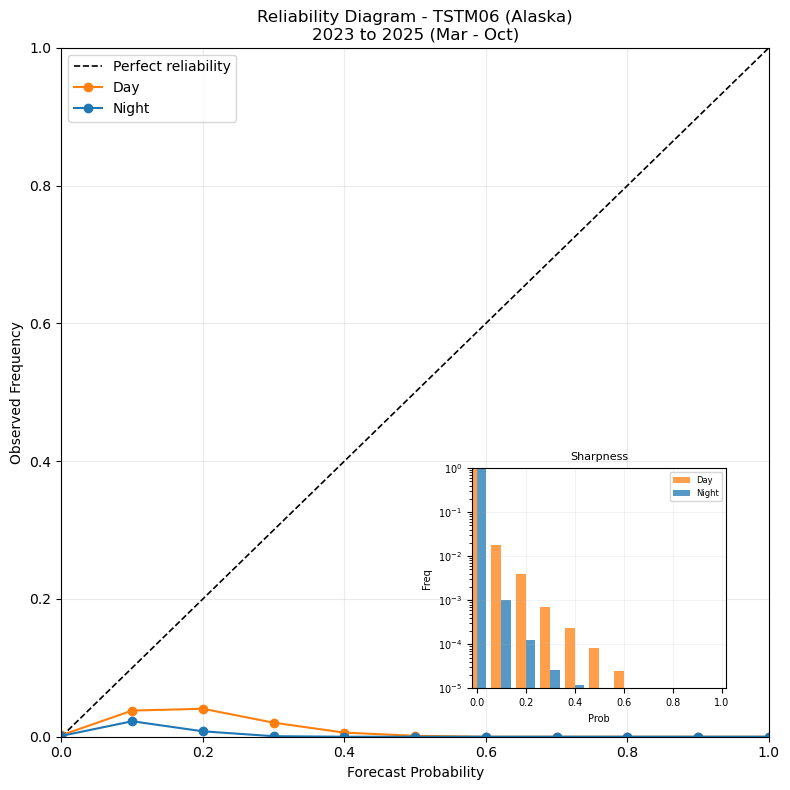

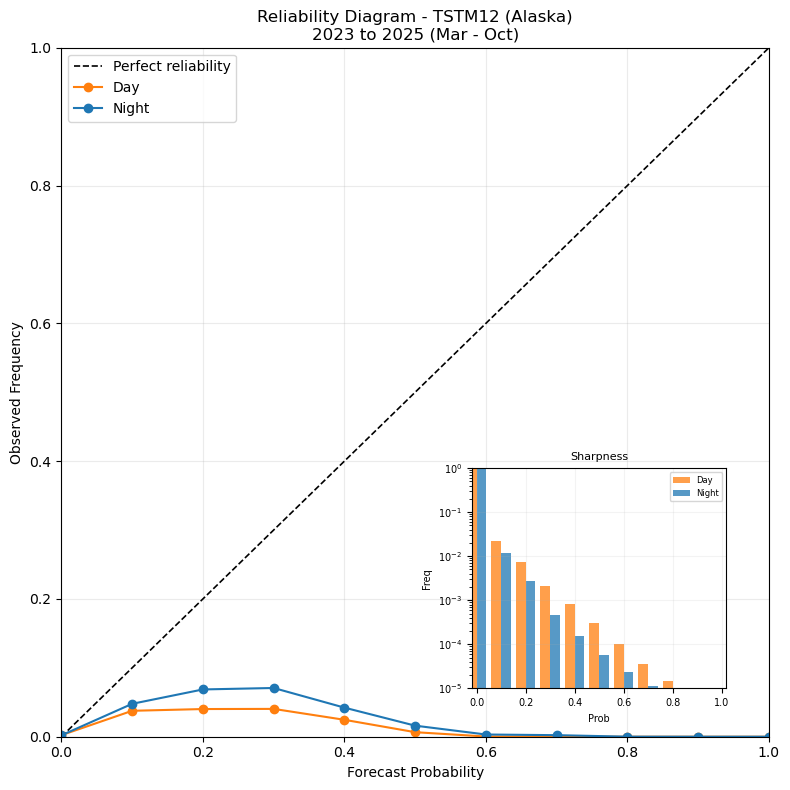


Per-region stats:
tstm_type region  rows  total_count     sum_obs  overall_obs_freq  day_bins  night_bins
       06 Alaska  3685  28015479375  64514218.0          0.002303        11          11
       12 Alaska  4923  34804791645 108089554.0          0.003106        11          11


In [4]:
# Build reliability plots (day vs night) for each selected region and TSTM type.
region_stats = []

for type_tag in sorted(df['tstm_type'].dropna().astype(str).unique()):
    type_df = df[df['tstm_type'].astype(str) == type_tag].copy()
    if type_df.empty:
        continue

    type_labels = sorted(type_df['source_file'].dropna().astype(str).unique())
    if len(type_labels) == 1:
        source_label = type_labels[0]
    else:
        source_label = f"{type_labels[0]} to {type_labels[-1]} ({len(type_labels)} files)"

    file_tag = f"tstm{type_tag}_{years.start}_{years.stop - 1}_{months.start:02d}_{months.stop - 1:02d}"

    for region_name in regions_to_plot:
        region_df = type_df[type_df['region'] == region_name].copy()
        if region_df.empty:
            continue

        # Aggregate to reliability coordinates by period and probability bin.
        rel = (
            region_df.groupby(['period', 'prob_bin'], as_index=False)[['sum_obs', 'count']]
            .sum()
        )
        rel['obs_freq'] = rel['sum_obs'] / rel['count']

        day = rel[rel['period'].str.lower() == 'day'].sort_values('prob_bin')
        night = rel[rel['period'].str.lower() == 'night'].sort_values('prob_bin')

        # Store summary stats for quick tabular review.
        region_stats.append({
            'tstm_type': type_tag,
            'region': region_name,
            'rows': len(region_df),
            'total_count': int(region_df['count'].sum()),
            'sum_obs': float(region_df['sum_obs'].sum()),
            'overall_obs_freq': float(region_df['sum_obs'].sum() / region_df['count'].sum()),
            'day_bins': int(len(day)),
            'night_bins': int(len(night)),
        })

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect reliability')

        if not day.empty:
            ax.plot(day['prob_bin'], day['obs_freq'], '-o', color='tab:orange', label='Day')
        if not night.empty:
            ax.plot(night['prob_bin'], night['obs_freq'], '-o', color='tab:blue', label='Night')

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Forecast Probability')
        ax.set_ylabel('Observed Frequency')
        ax.set_title(f"Reliability Diagram - TSTM{type_tag} ({region_name})\n{date_span_label}")
        ax.grid(alpha=0.25)
        ax.legend()

        # Sharpness inset: relative forecast frequency by bin (log y-scale).
        inset_ax = ax.inset_axes([0.58, 0.07, 0.36, 0.32])

        if not day.empty and day['count'].sum() > 0:
            day_rel = day[['prob_bin', 'count']].copy()
            day_rel['freq'] = day_rel['count'] / day_rel['count'].sum()
            inset_ax.bar(
                day_rel['prob_bin'] - 0.02,
                day_rel['freq'],
                width=0.04,
                color='tab:orange',
                alpha=0.75,
                label='Day',
            )

        if not night.empty and night['count'].sum() > 0:
            night_rel = night[['prob_bin', 'count']].copy()
            night_rel['freq'] = night_rel['count'] / night_rel['count'].sum()
            inset_ax.bar(
                night_rel['prob_bin'] + 0.02,
                night_rel['freq'],
                width=0.04,
                color='tab:blue',
                alpha=0.75,
                label='Night',
            )

        inset_ax.set_xlim(-0.02, 1.02)
        inset_ax.set_yscale('log')
        inset_ax.set_ylim(1e-5, 1)
        inset_ax.set_title('Sharpness', fontsize=8)
        inset_ax.set_xlabel('Prob', fontsize=7)
        inset_ax.set_ylabel('Freq', fontsize=7)
        inset_ax.tick_params(axis='both', labelsize=7)
        inset_ax.grid(True, alpha=0.15)
        inset_ax.legend(loc='upper right', fontsize=6, frameon=True)

        # Optional file path for saving plots; currently display-only.
        region_slug = ''.join(ch if str(ch).isalnum() else '_' for ch in str(region_name)).strip('_')
        out_png = csv_dir / f"verif_{file_tag}_reliability_day_night_{region_slug}.png"
        plt.tight_layout()
        # plt.savefig(out_png, dpi=150)
        plt.show()
        # print(f"Saved (TSTM{type_tag}, {region_name}): {out_png}")

stats_df = pd.DataFrame(region_stats)
print('\nPer-region stats:')
print(stats_df.to_string(index=False))

In [5]:
# Lightweight diagnostics by TSTM type to validate loaded content.
print('Columns:', sorted(df.columns.tolist()))
print('Rows:', len(df))
print('Regions:', sorted(df['region'].dropna().unique().tolist()))
print('Periods:', sorted(df['period'].dropna().str.lower().unique().tolist()))

for type_tag in sorted(df['tstm_type'].dropna().astype(str).unique()):
    type_df = df[df['tstm_type'].astype(str) == type_tag].copy()

    # Aggregate selected regions by probability bin.
    attr = (
        type_df[type_df['region'].isin(regions_to_plot)]
        .groupby('prob_bin', as_index=False)[['sum_obs', 'count']]
        .sum()
        .sort_values('prob_bin')
    )
    attr['obs_pct'] = 100.0 * attr['sum_obs'] / attr['count']
    attr['freq_pct'] = 100.0 * attr['count'] / attr['count'].sum()

    climo = 100.0 * attr['sum_obs'].sum() / attr['count'].sum()

    print(f"\n=== TSTM{type_tag} ===")
    print('Climatology (%):', round(climo, 3))
    print('Bin summary (first 12 rows):')
    print(attr.head(12).to_string(index=False))

    required_ok = {'prob_bin', 'sum_obs', 'count'}.issubset(type_df.columns)
    has_0_1_bins = float(attr['prob_bin'].min()) <= 0.01 and float(attr['prob_bin'].max()) >= 0.99
    print('Required columns present:', required_ok)
    print('Probability-bin span includes ~0 and ~1:', has_0_1_bins)

Columns: ['count', 'forecast_hour', 'interval_hour', 'month', 'period', 'prob_bin', 'region', 'source_file', 'sum_obs', 'sum_se', 't10_cn', 't10_fa', 't10_hits', 't10_misses', 't20_cn', 't20_fa', 't20_hits', 't20_misses', 't30_cn', 't30_fa', 't30_hits', 't30_misses', 't40_cn', 't40_fa', 't40_hits', 't40_misses', 't50_cn', 't50_fa', 't50_hits', 't50_misses', 't60_cn', 't60_fa', 't60_hits', 't60_misses', 't70_cn', 't70_fa', 't70_hits', 't70_misses', 't80_cn', 't80_fa', 't80_hits', 't80_misses', 't90_cn', 't90_fa', 't90_hits', 't90_misses', 'tstm_type', 'year']
Rows: 8608
Regions: ['Alaska']
Periods: ['day', 'night']

=== TSTM06 ===
Climatology (%): 0.23
Bin summary (first 12 rows):
 prob_bin    sum_obs       count  obs_pct  freq_pct
      0.0 49842083.0 27616534667 0.180479 98.575985
      0.1 11716906.0   313427069 3.738320  1.118764
      0.2  2694178.0    67508584 3.990867  0.240969
      0.3   235921.0    11858350 1.989493  0.042328
      0.4    23306.0     4057968 0.574327  0.014485

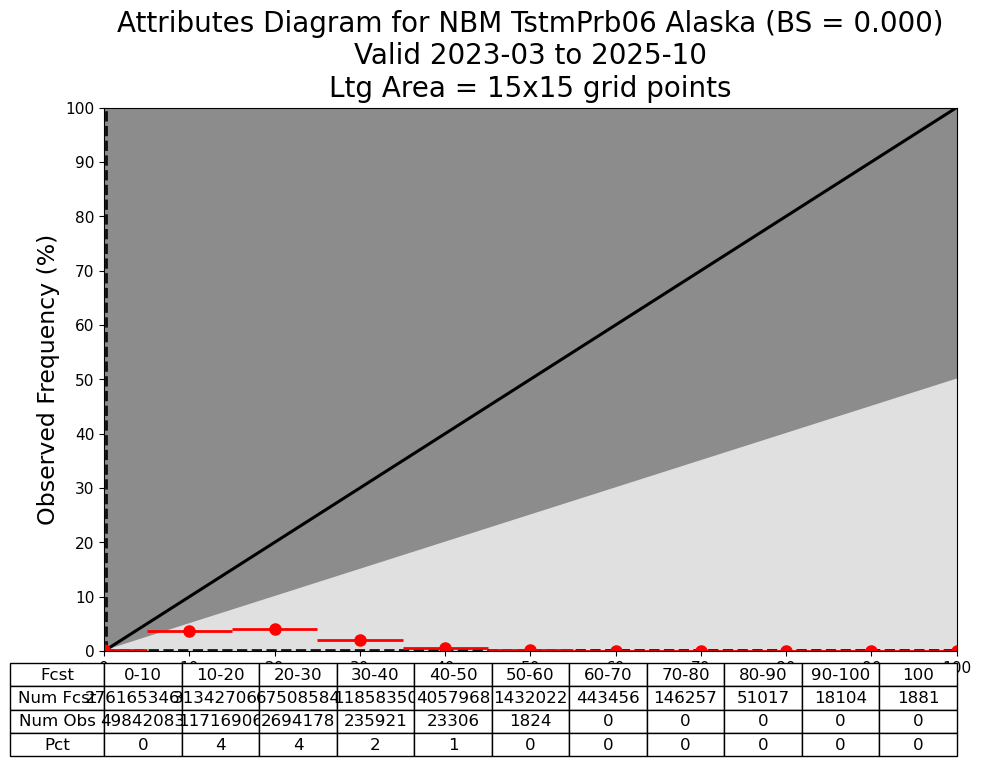

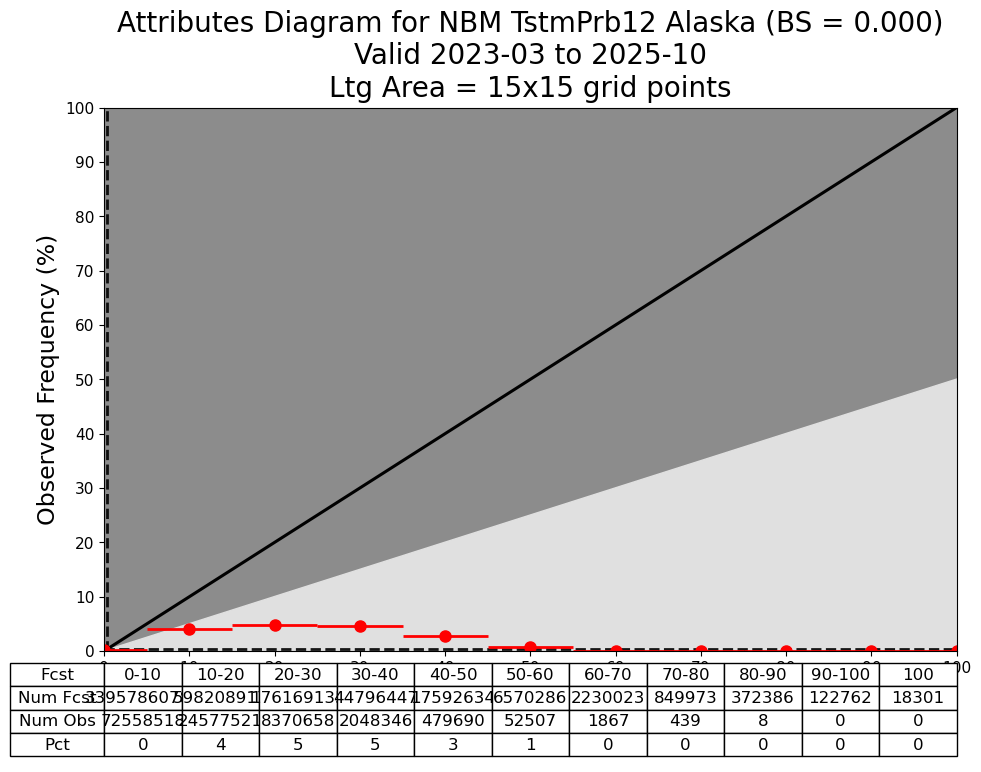

In [6]:
# Attributes diagram(s) for each selected region and TSTM type.
save_attributes_png = False

for type_tag in sorted(df['tstm_type'].dropna().astype(str).unique()):
    type_df = df[df['tstm_type'].astype(str) == type_tag].copy()
    if type_df.empty:
        continue

    for region_name in regions_to_plot:
        region_df = type_df[type_df['region'] == region_name].copy()
        if region_df.empty:
            continue

        # Aggregate by probability bin across selected files for this region/type.
        attr = (
            region_df.groupby('prob_bin', as_index=False)[['sum_obs', 'count']]
            .sum()
            .sort_values('prob_bin')
        )
        attr['obs_pct'] = 100.0 * attr['sum_obs'] / attr['count']
        attr['fcst_pct'] = 100.0 * attr['prob_bin']
        attr['freq_pct'] = 100.0 * attr['count'] / attr['count'].sum()

        # Climatology and weighted Brier score using aggregated bin counts.
        climo = 100.0 * attr['sum_obs'].sum() / attr['count'].sum()
        climo_f = climo / 100.0
        bs = np.average(
            (attr['prob_bin'] - (attr['obs_pct'] / 100.0)) ** 2,
            weights=attr['count'],
        )

        # No-skill reference line in attributes-diagram space.
        x = np.linspace(0, 1, 401)
        no_skill = 0.5 * (x + climo_f)

        fig = plt.figure(figsize=(11, 8.5))
        gs = fig.add_gridspec(2, 1, height_ratios=[5.2, 1.0], hspace=0.02)
        ax = fig.add_subplot(gs[0])
        tb_ax = fig.add_subplot(gs[1])
        tb_ax.axis('off')

        # Skill-background shading.
        ax.fill_between(x * 100.0, no_skill * 100.0, 100.0, color='0.55', zorder=0)
        ax.fill_between(x * 100.0, 0.0, no_skill * 100.0, color='0.88', zorder=0)

        # Reference lines: perfect reliability and climatology.
        ax.plot([0, 100], [0, 100], color='black', lw=2.2)
        ax.axhline(climo, color='black', ls='--', lw=2, alpha=0.9)
        ax.axvline(climo, color='black', ls='--', lw=2, alpha=0.9)

        # Reliability points + horizontal 10%-bin bars.
        x_pts = attr['fcst_pct'].to_numpy()
        y_pts = attr['obs_pct'].to_numpy()
        ax.hlines(y_pts, x_pts - 5.0, x_pts + 5.0, color='red', lw=2)
        ax.plot(x_pts, y_pts, 'o', color='red', ms=8)

        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_ylabel('Observed Frequency (%)', fontsize=17)
        ax.set_xticks(np.arange(0, 101, 10))
        ax.set_yticks(np.arange(0, 101, 10))
        ax.tick_params(labelsize=11)

        year_min = int(region_df['year'].min()) if 'year' in region_df.columns else None
        year_max = int(region_df['year'].max()) if 'year' in region_df.columns else None
        month_min = int(region_df['month'].min()) if 'month' in region_df.columns else None
        month_max = int(region_df['month'].max()) if 'month' in region_df.columns else None

        if year_min is not None and month_min is not None:
            valid_label = f"Valid {year_min}-{month_min:02d} to {year_max}-{month_max:02d}"
        else:
            valid_label = f"Selected files ({len(type_df['source_file'].dropna().unique())})"

        ax.set_title(
            f"Attributes Diagram for NBM TstmPrb{type_tag} {region_name} (BS = {bs:.3f})\n"
            f"{valid_label}\nLtg Area = 15x15 grid points",
            fontsize=20,
            pad=8,
        )

        # Bottom table summarizes forecast-bin sample sizes and observed outcomes.
        bin_labels = []
        for v in attr['prob_bin']:
            if float(v) >= 1.0:
                bin_labels.append('100')
            else:
                lo = int(round(float(v) * 100.0))
                hi = min(lo + 10, 100)
                bin_labels.append(f"{lo}-{hi}")

        table_data = [
            bin_labels,
            [f"{int(v):d}" for v in attr['count']],
            [f"{int(v):d}" for v in attr['sum_obs']],
            [f"{int(round(v)):d}" for v in attr['obs_pct']],
        ]
        row_labels = ['Fcst', 'Num Fcst', 'Num Obs', 'Pct']

        table = tb_ax.table(
            cellText=table_data,
            rowLabels=row_labels,
            cellLoc='center',
            rowLoc='center',
            loc='center',
        )
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.scale(1.0, 1.4)

        plt.show()

        if save_attributes_png:
            region_slug = ''.join(ch if str(ch).isalnum() else '_' for ch in str(region_name)).strip('_')
            out_png = csv_dir / f"attributes_tstm{type_tag}_{region_slug}.png"
            fig.savefig(out_png, dpi=150, bbox_inches='tight')
            print(f"Saved attributes (TSTM{type_tag}, {region_name}): {out_png}")